# Image Classification Workshop Lab

This notebook is designed as a first hands-on image-classification lesson for beginners.

We will:
- load an image dataset from folders,
- choose a classification target,
- inspect class balance and image examples,
- train a simple scikit-learn baseline,
- train a tiny CNN when PyTorch is available,
- compare accuracy, runtime, and workflow tradeoffs,
- stress-test device predictions on damaged images from the `Defect` folder.

The notebook supports two targets:
- `device_type`: classify `device1`, `device 2`, `device 3`, and future device folders using only the clean device folders for training.
- `damage_status`: classify `Damaged` vs `Not-Damaged` by treating `Defect` as damaged and the normal device folders as not damaged.


## 1. Imports and workshop helpers

This cell loads the tools we need and prepares a runtime log so we can measure how long each major step takes.

In [31]:
from pathlib import Path
import math
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "0_Class_Notebooks":
    candidate = NOTEBOOK_DIR / "0_Class_Notebooks"
    if candidate.exists():
        NOTEBOOK_DIR = candidate

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from workshop_image_utils import (
    available_target_modes,
    create_progress,
    load_image_records,
    load_images_as_arrays,
    record_timing,
    safe_stratify_labels,
    target_column_for_mode,
    timing_frame,
    update_progress,
    validate_target_mode,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    torch = None
    nn = None
    DataLoader = None
    TensorDataset = None
    print("PyTorch is not installed in this environment, so the CNN section will be skipped.")

step_timings = []


## 2. Configuration

Change the values in this cell when you want to switch datasets or tasks.

Beginner note:
- `device_type` trains on clean device folders and can use the `Defect` folder as a separate challenge set.
- `damage_status` asks a binary question: damaged or not damaged.
- Some values in the configuration cell are also hyperparameters, which means they control model behavior rather than just file paths.

Quick guide to the shared settings:
- `IMAGE_SIZE`: resize target for the classical image models. Larger values preserve more detail but create more input features.
- `TEST_SIZE`: fraction of the dataset held out for testing.
- `RANDOM_STATE`: keeps the split reproducible so students see the same result again.
- `CNN_IMAGE_SIZE`: resize target for the CNN.
- `CNN_EPOCHS`: number of full passes through the training set.
- `CNN_BATCH_SIZE`: how many images the CNN processes before each weight update.
- `CNN_LEARNING_RATE`: how large each CNN optimization step is.


In [32]:
DATASET_ROOT = (NOTEBOOK_DIR.parent / "Augmented_Device_Images").resolve()
METADATA_PATH = DATASET_ROOT / "metadata.csv"  # Optional future file.
TARGET_MODE = "damage_status"  # Change to "device_type" to train on device types instead of damage status.
INCLUDED_DEVICE_TYPES = ["device1", "device 2"]
RUN_DEFECT_CHALLENGE = TARGET_MODE == "device_type"
IMAGE_SIZE = 96
TEST_SIZE = 0.30
RANDOM_STATE = 42
CNN_IMAGE_SIZE = 64
CNN_EPOCHS = 6
CNN_BATCH_SIZE = 8
CNN_LEARNING_RATE = 0.001

print(f"Dataset root: {DATASET_ROOT}")
print(f"Metadata file exists: {METADATA_PATH.exists()}")
print(f"Current target mode: {TARGET_MODE}")
print(f"Included device folders: {INCLUDED_DEVICE_TYPES}")
print(f"Run defect challenge after device training: {RUN_DEFECT_CHALLENGE}")


Dataset root: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Metadata file exists: True
Current target mode: damage_status
Included device folders: ['device1', 'device 2']
Run defect challenge after device training: False


## 3. Load the dataset and inspect available labels

Stop and predict before you run this cell:
- Which task do you think will be easier for a model: device type or damage status?
- What problems could appear if one class has many more images than another?
- Do you think a model trained on clean devices will still recognize damaged ones?


In [33]:
started = time.perf_counter()
all_records = load_image_records(DATASET_ROOT, metadata_path=METADATA_PATH if METADATA_PATH.exists() else None)
load_elapsed = record_timing(step_timings, "dataset_scan", started)

print(f"Loaded {len(all_records)} image records in {load_elapsed:.2f} seconds before workshop filtering.")

standard_device_records = all_records[all_records["is_standard_device_image"]].reset_index(drop=True)
standard_device_records = standard_device_records[standard_device_records["device_type"].isin(INCLUDED_DEVICE_TYPES)].reset_index(drop=True)
defect_challenge_records = all_records[all_records["is_defect_challenge"]].reset_index(drop=True)

print(f"Standard device records after included-device filtering: {len(standard_device_records)}")
print(f"Defect challenge records available: {len(defect_challenge_records)}")

if TARGET_MODE == "device_type":
    records = standard_device_records.copy()
else:
    records = pd.concat([standard_device_records, defect_challenge_records], ignore_index=True)

display(records.head())
print("Available target modes right now:", available_target_modes(records))

is_valid_target, target_message = validate_target_mode(records, TARGET_MODE)
print(target_message)
if not is_valid_target:
    raise ValueError(target_message)

target_column = target_column_for_mode(TARGET_MODE)
records = records[records[target_column].notna()].reset_index(drop=True)
print(f"Records remaining after filtering to labeled rows for {TARGET_MODE}: {len(records)}")

if TARGET_MODE == "device_type" and RUN_DEFECT_CHALLENGE:
    print("Defect images will stay outside the train/test split and be used later as a challenge set.")


Loaded 159 image records in 0.02 seconds before workshop filtering.
Standard device records after included-device filtering: 92
Defect challenge records available: 40


,filepath,relative_path,device_type,damage_status,top_level_folder,has_damage_label,has_device_type_label,device_type_label_source,is_defect_folder,is_standard_device_image,is_defect_challenge
0,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
1,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1.png,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
2,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_002.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
3,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_008.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False
4,C:\Users\l-a-c\1.repositories\Summer_Workshop_...,device 2/1_1_aug_010.jpg,device 2,Not-Damaged,device 2,True,True,folder-or-metadata,False,True,False


Available target modes right now: ['device_type', 'damage_status']
Target `damage_status` is ready with classes: ['Damaged', 'Not-Damaged']
Records remaining after filtering to labeled rows for damage_status: 132


## 4. Class balance and image inventory

This section helps us answer:
- How many examples do we have for each class?
- Is the dataset balanced?
- Are we at risk of teaching the model from a tiny or biased sample?

For `device_type`, this chart only shows the clean training pool. The damaged `Defect` images are held back for the later stress test.
For `damage_status`, the chart can include both original and augmented clean device images because they all act as `Not-Damaged` examples.


,count
damage_status,
Damaged,40
Not-Damaged,92


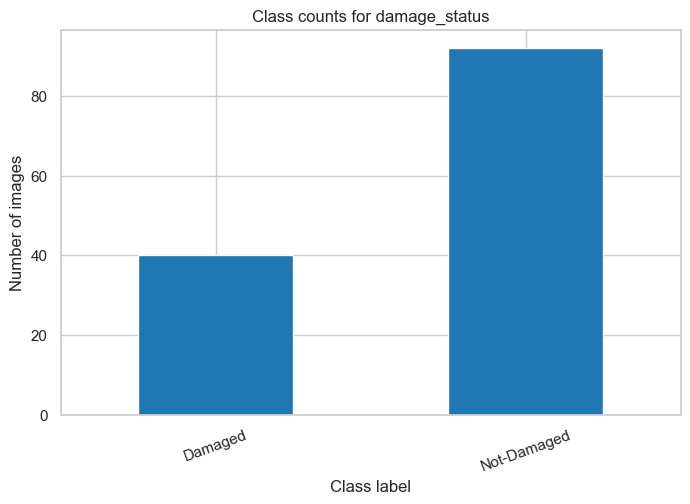

Damage-status note:
Both original and augmented clean device images count as `Not-Damaged` in this binary task.
Defect images and their augmentations count as `Damaged`.
Reflection prompt:
If one class dominates this chart, the model may learn shortcuts instead of the real visual concept.


In [34]:
class_counts = records[target_column].value_counts(dropna=True).sort_index()
display(class_counts.rename("count").to_frame())

ax = class_counts.plot(kind="bar", color="#1f77b4", title=f"Class counts for {TARGET_MODE}")
ax.set_xlabel("Class label")
ax.set_ylabel("Number of images")
plt.xticks(rotation=20)
plt.show()

if TARGET_MODE == "damage_status":
    print("Damage-status note:")
    print("Both original and augmented clean device images count as `Not-Damaged` in this binary task.")
    print("Defect images and their augmentations count as `Damaged`.")

print("Reflection prompt:")
print("If one class dominates this chart, the model may learn shortcuts instead of the real visual concept.")


## 5. Preview example images

Seeing the data matters. Beginners should always inspect a few images before trusting a model.

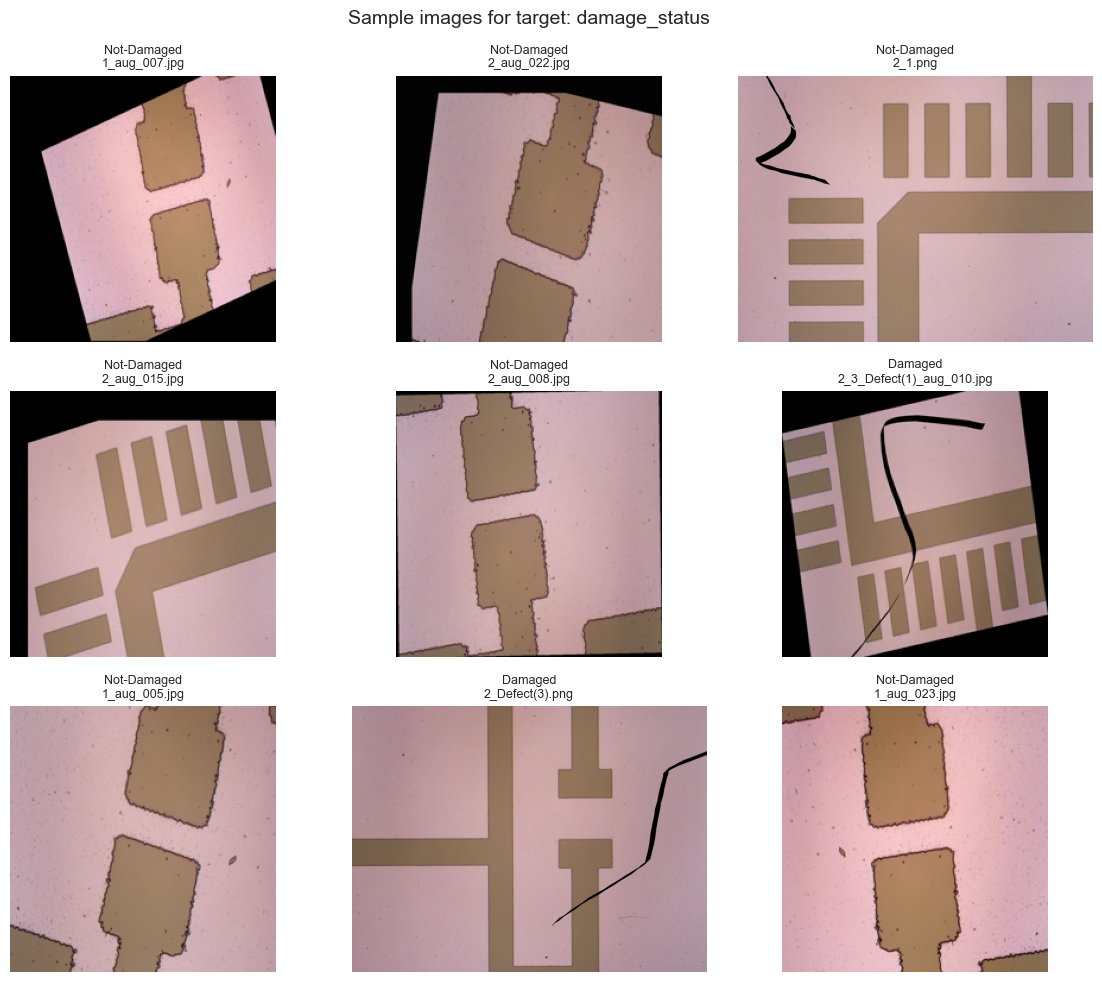

In [35]:
preview_count = min(9, len(records))
sample_records = records.sample(preview_count, random_state=RANDOM_STATE).reset_index(drop=True)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, row in zip(axes, sample_records.itertuples(index=False)):
    with Image.open(row.filepath) as image:
        ax.imshow(image.convert("RGB"))
    label = getattr(row, target_column)
    ax.set_title(f"{label}\n{Path(row.relative_path).name}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Sample images for target: {TARGET_MODE}", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Preprocess images for the classical baseline

We will resize every image to the same shape and convert it into a numerical array.

Why do this?
- Machine-learning models need consistent input shapes.
- A simple baseline helps us understand the workflow before using deep learning.


In [36]:
started = time.perf_counter()
image_arrays, filtered_records = load_images_as_arrays(
    records,
    image_size=IMAGE_SIZE,
    color_mode="grayscale",
    progress_title="Preprocess",
)
preprocess_elapsed = record_timing(step_timings, "preprocess_images", started)

labels = filtered_records[target_column].astype(str).to_numpy()
X = image_arrays.reshape(len(image_arrays), -1) / 255.0

defect_challenge_X = None
defect_challenge_gray_records = None
if TARGET_MODE == "device_type" and RUN_DEFECT_CHALLENGE and not defect_challenge_records.empty:
    defect_arrays, defect_challenge_gray_records = load_images_as_arrays(
        defect_challenge_records,
        image_size=IMAGE_SIZE,
        color_mode="grayscale",
        progress_title="Defect challenge",
    )
    defect_challenge_X = defect_arrays.reshape(len(defect_arrays), -1) / 255.0

print(f"Processed {len(filtered_records)} images in {preprocess_elapsed:.2f} seconds.")
print("Feature matrix shape:", X.shape)
print("Image tensor shape before flattening:", image_arrays.shape)
print(f"Active dataset root used for training: {DATASET_ROOT}")
if TARGET_MODE == "damage_status":
    training_damage_counts = filtered_records["damage_status"].value_counts(dropna=True).sort_index()
    print("Final damage-status counts used for training:")
    display(training_damage_counts.rename("count").to_frame())
if defect_challenge_X is not None:
    print(f"Prepared {len(defect_challenge_gray_records)} damaged challenge images for later device-type inference.")


Processed 132 images in 1.75 seconds.
Feature matrix shape: (132, 9216)
Image tensor shape before flattening: (132, 96, 96)
Active dataset root used for training: C:\Users\l-a-c\1.repositories\Summer_Workshop_Data_Driven_Decision_Making\Augmented_Device_Images
Final damage-status counts used for training:


,count
damage_status,
Damaged,40
Not-Damaged,92


## 7. Train/test split

Stop and predict before running:
- If the dataset is tiny, do you expect the score to be stable every time?
- Why might a different random split change the final accuracy?

In [37]:
stratify_labels = safe_stratify_labels(labels)
X_train, X_test, y_train, y_test, train_records, test_records = train_test_split(
    X,
    labels,
    filtered_records,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)

print("Train set size:", len(X_train))
print("Test set size:", len(X_test))
print("Used stratified split:", stratify_labels is not None)

Train set size: 92
Test set size: 40
Used stratified split: True


## 8. Shared evaluation helpers

These helper functions keep the evaluation format consistent across all models so students can compare them fairly.


In [38]:
model_summaries = []


def _render_gallery_image(image_data, color_mode="grayscale", image_size=None):
    if color_mode == "grayscale":
        if image_size is None:
            raise ValueError("image_size is required for grayscale galleries.")
        return image_data.reshape(image_size, image_size), {"cmap": "gray"}
    return image_data, {}


def _softmax_rows(values):
    values = np.asarray(values, dtype=float)
    shifted = values - values.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def estimate_prediction_confidence(estimator, X_values):
    if hasattr(estimator, "predict_proba"):
        probabilities = estimator.predict_proba(X_values)
        return probabilities.max(axis=1), "Confidence"

    if hasattr(estimator, "decision_function"):
        decision = estimator.decision_function(X_values)
        if np.ndim(decision) == 1:
            confidence = 1.0 / (1.0 + np.exp(-np.abs(decision)))
        else:
            confidence = _softmax_rows(decision).max(axis=1)
        return confidence, "Confidence"

    return None, None


def show_prediction_gallery(images, truths, preds, indices, title, color_mode="grayscale", image_size=None, max_images=6, confidences=None, confidence_label="Confidence"):
    selected = list(indices)[:max_images]
    if not selected:
        display(Markdown(f"**{title}:** none available in this split."))
        return

    columns = min(3, len(selected))
    rows = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, selected):
        rendered, kwargs = _render_gallery_image(images[idx], color_mode=color_mode, image_size=image_size)
        ax.imshow(rendered, **kwargs)
        title_lines = [f"True: {truths[idx]}", f"Pred: {preds[idx]}"]
        if confidences is not None:
            title_lines.append(f"{confidence_label}: {float(confidences[idx]):.2f}")
        ax.set_title("\n".join(title_lines), fontsize=10)
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def evaluate_predictions(model_name, truths, preds, images, color_mode="grayscale", image_size=None, cmap="Blues", confidences=None, confidence_label="Confidence"):
    labels_sorted = sorted(pd.unique(np.array(truths, dtype=object)))
    cm = confusion_matrix(truths, preds, labels=labels_sorted)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=labels_sorted, yticklabels=labels_sorted)
    plt.title(f"{model_name} confusion matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

    correct_indices = [idx for idx, (truth, pred) in enumerate(zip(truths, preds)) if truth == pred]
    incorrect_indices = [idx for idx, (truth, pred) in enumerate(zip(truths, preds)) if truth != pred]

    show_prediction_gallery(
        images,
        truths,
        preds,
        correct_indices,
        title=f"{model_name}: correctly predicted images",
        color_mode=color_mode,
        image_size=image_size,
        confidences=confidences,
        confidence_label=confidence_label,
    )
    show_prediction_gallery(
        images,
        truths,
        preds,
        incorrect_indices,
        title=f"{model_name}: incorrectly predicted images",
        color_mode=color_mode,
        image_size=image_size,
        confidences=confidences,
        confidence_label=confidence_label,
    )


def fit_and_evaluate_classical_model(model_name, estimator, X_train, y_train, X_test, y_test, image_arrays, image_size, timing_key, cmap="Blues"):
    started = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_elapsed = record_timing(step_timings, f"{timing_key}_train", started)

    started = time.perf_counter()
    predictions = estimator.predict(X_test)
    predict_elapsed = record_timing(step_timings, f"{timing_key}_predict", started)

    confidences, confidence_label = estimate_prediction_confidence(estimator, X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{model_name} training time: {train_elapsed:.2f} seconds")
    print(f"{model_name} prediction time: {predict_elapsed:.4f} seconds")
    print(f"{model_name} accuracy: {accuracy:.3f}")
    if confidences is not None:
        print(f"Average {confidence_label.lower()}: {float(np.mean(confidences)):.3f}")
    print(classification_report(y_test, predictions))

    evaluate_predictions(
        model_name,
        truths=list(y_test),
        preds=list(predictions),
        images=image_arrays,
        color_mode="grayscale",
        image_size=image_size,
        cmap=cmap,
        confidences=confidences,
        confidence_label=confidence_label or "Confidence",
    )

    result = {
        "model": model_name,
        "accuracy": float(accuracy),
        "train_seconds": float(train_elapsed),
        "predict_seconds": float(predict_elapsed),
        "estimator": estimator,
        "predictions": predictions,
        "confidences": confidences,
        "confidence_label": confidence_label,
    }
    model_summaries.append({
        "model": model_name,
        "accuracy": round(float(accuracy), 3),
        "train_seconds": round(float(train_elapsed), 3),
        "predict_seconds": round(float(predict_elapsed), 4),
    })
    return result


## 9. Logistic regression

This stays as the main linear classification baseline for the workshop.

Hyperparameter notes:
- `max_iter=2000`: gives the optimizer more chances to converge. If this is too small, training can stop before the model settles.
- `StandardScaler()`: not a hyperparameter itself, but it helps by putting pixel features on a comparable scale before logistic regression learns.


Logistic Regression training time: 0.10 seconds
Logistic Regression prediction time: 0.0019 seconds
Logistic Regression accuracy: 0.550
              precision    recall  f1-score   support

     Damaged       0.20      0.17      0.18        12
 Not-Damaged       0.67      0.71      0.69        28

    accuracy                           0.55        40
   macro avg       0.43      0.44      0.44        40
weighted avg       0.53      0.55      0.54        40



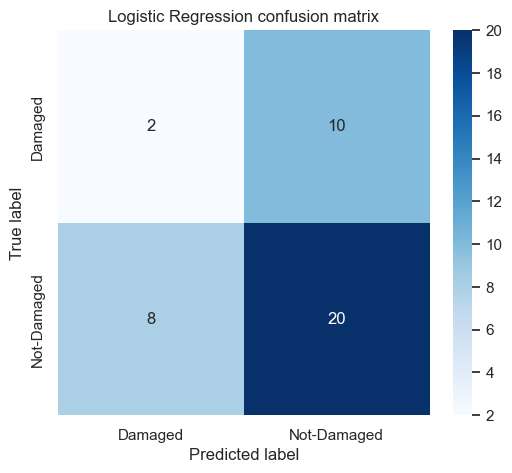

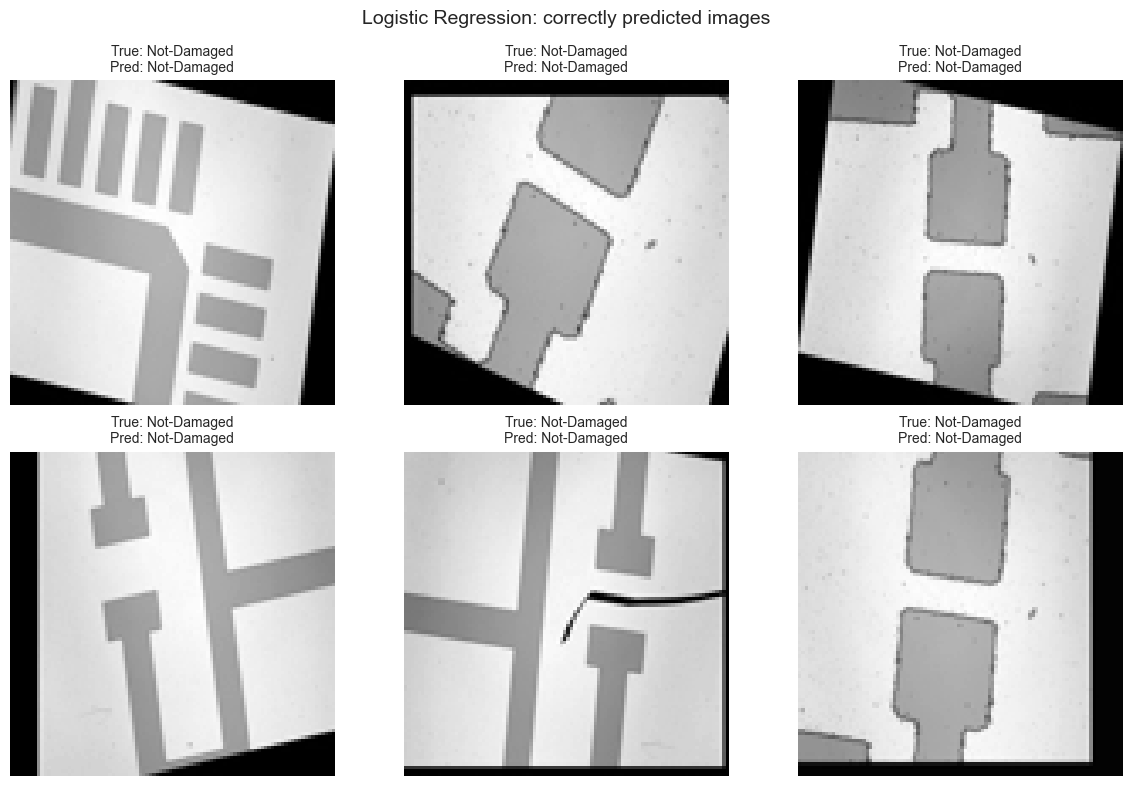

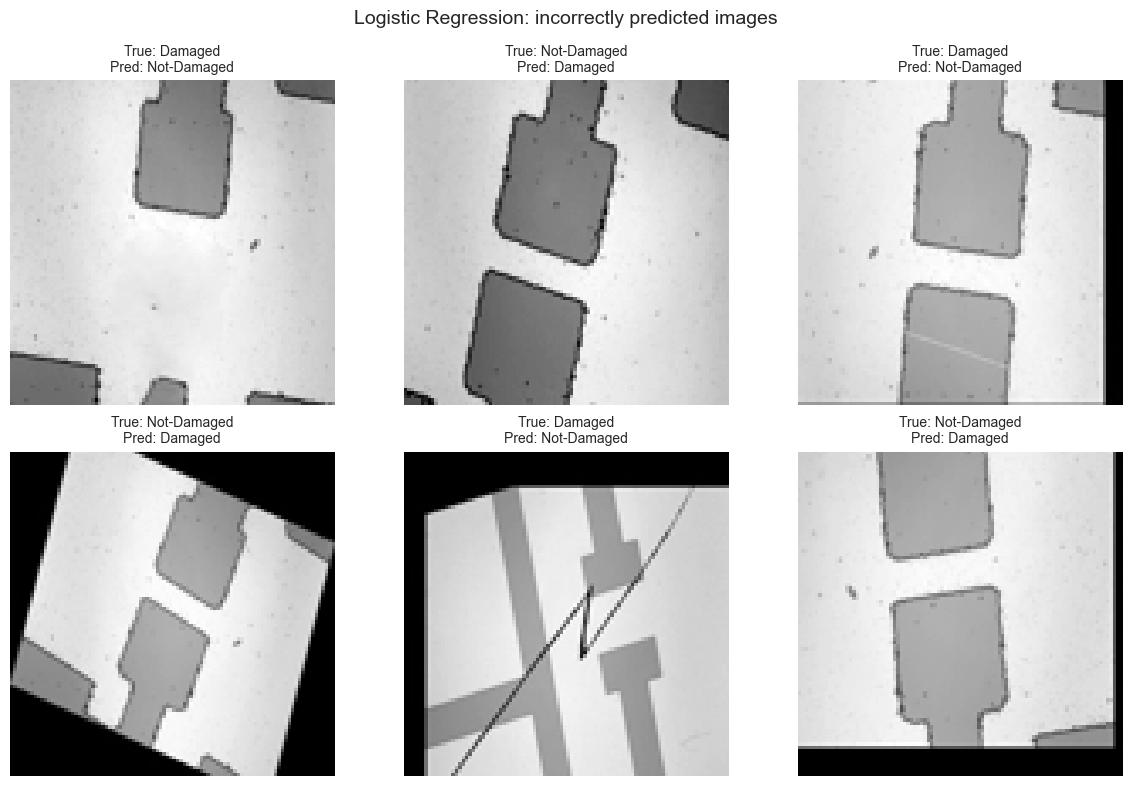

In [39]:
logistic_model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000)),
    ]
)
logistic_results = fit_and_evaluate_classical_model(
    model_name="Logistic Regression",
    estimator=logistic_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="logistic",
    cmap="Blues",
)


## 10. Decision tree

Decision trees are easier to explain visually, but they can also overfit tiny datasets quickly.

Hyperparameter notes:
- `random_state=RANDOM_STATE`: makes the learned tree reproducible.
- This notebook is using the default tree depth, so the tree can keep growing until the stopping rules are met. That can make it flexible, but also easier to overfit.


Decision Tree training time: 0.14 seconds
Decision Tree prediction time: 0.0011 seconds
Decision Tree accuracy: 0.550
              precision    recall  f1-score   support

     Damaged       0.33      0.50      0.40        12
 Not-Damaged       0.73      0.57      0.64        28

    accuracy                           0.55        40
   macro avg       0.53      0.54      0.52        40
weighted avg       0.61      0.55      0.57        40



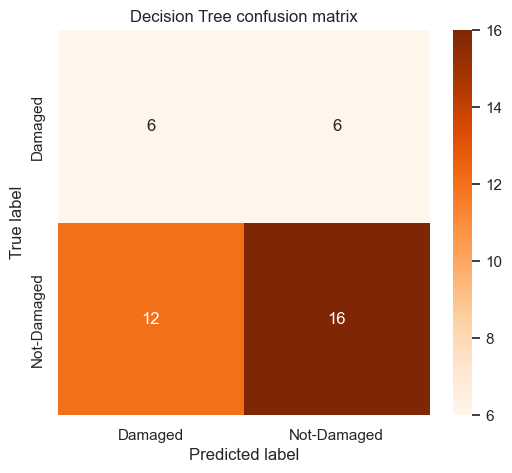

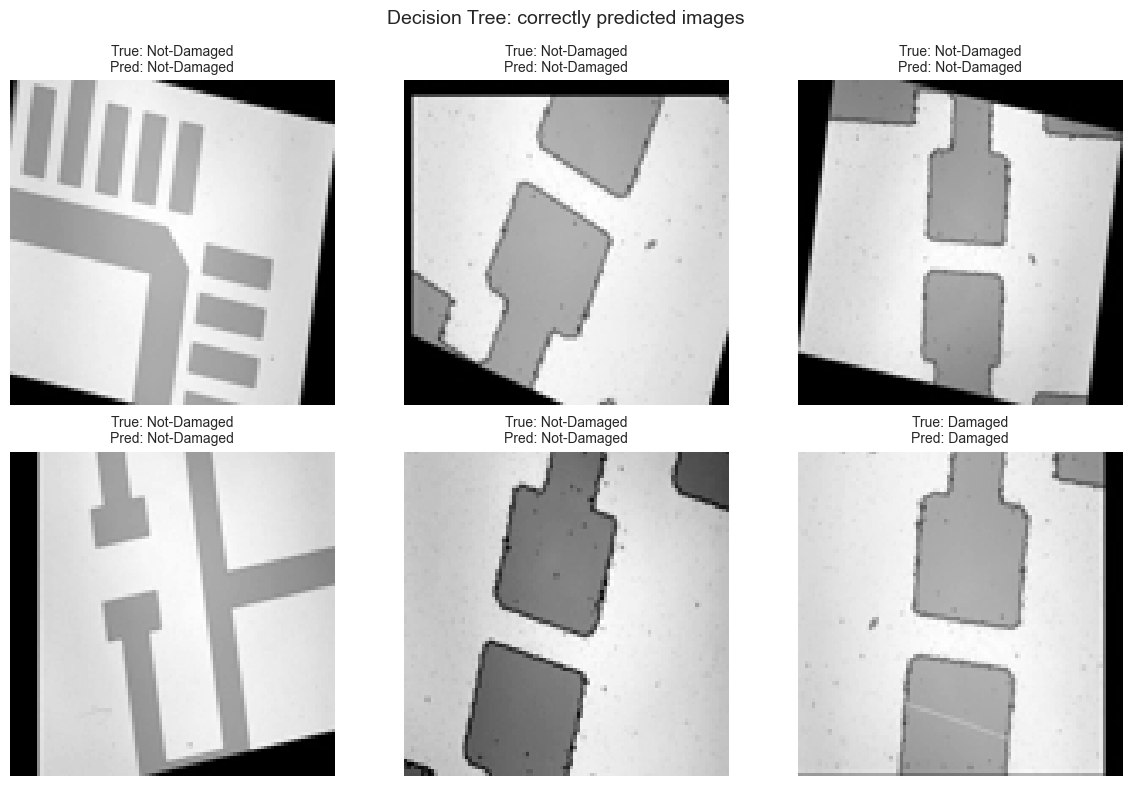

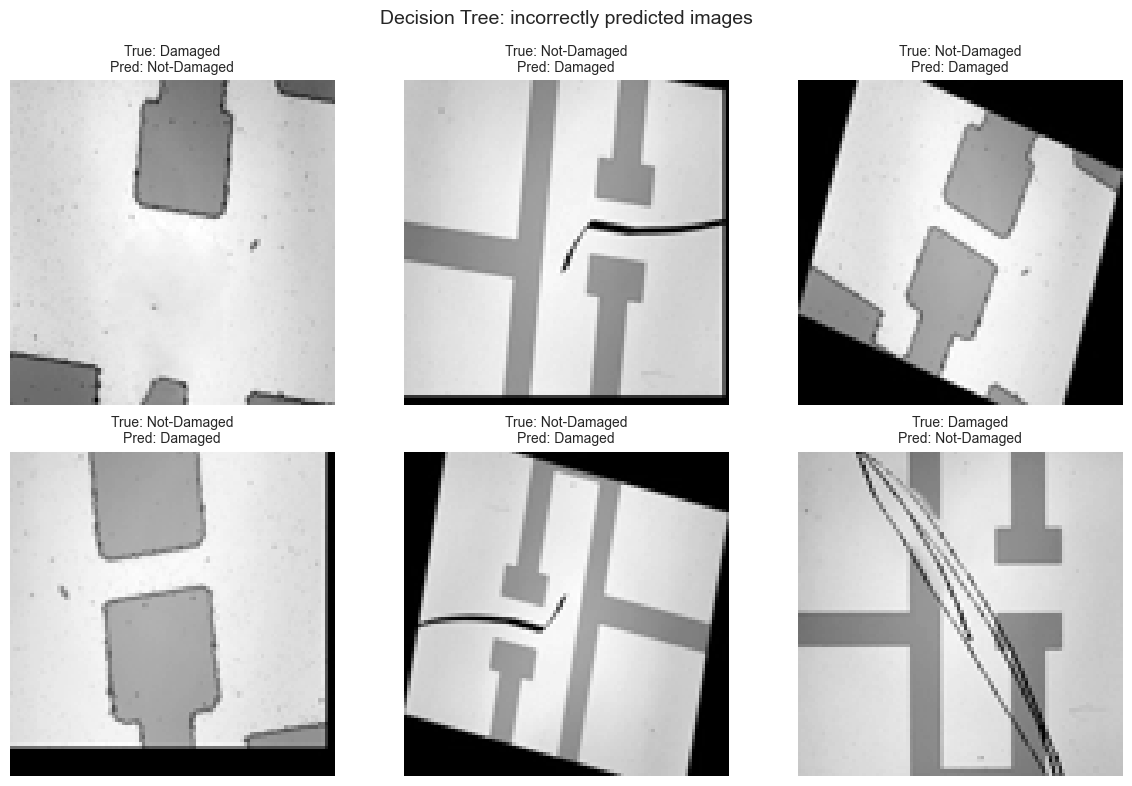

In [40]:
decision_tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_results = fit_and_evaluate_classical_model(
    model_name="Decision Tree",
    estimator=decision_tree_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="decision_tree",
    cmap="Oranges",
)


## 11. K-nearest neighbors

K-nearest neighbors compares each test image to the training set instead of learning a single decision boundary.

Hyperparameter notes:
- `n_neighbors=3`: each prediction is based on the 3 closest training examples. Smaller values react more to local detail; larger values make the boundary smoother.
- `StandardScaler()`: helps distance-based methods like KNN because feature scale affects which points count as nearest neighbors.


K-Nearest Neighbors training time: 0.01 seconds
K-Nearest Neighbors prediction time: 0.0140 seconds
K-Nearest Neighbors accuracy: 0.700
              precision    recall  f1-score   support

     Damaged       0.50      0.42      0.45        12
 Not-Damaged       0.77      0.82      0.79        28

    accuracy                           0.70        40
   macro avg       0.63      0.62      0.62        40
weighted avg       0.69      0.70      0.69        40



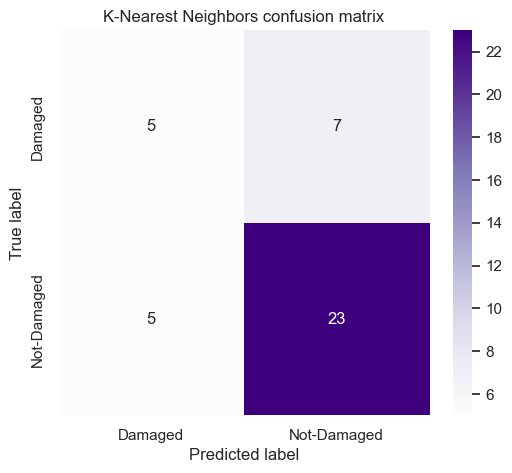

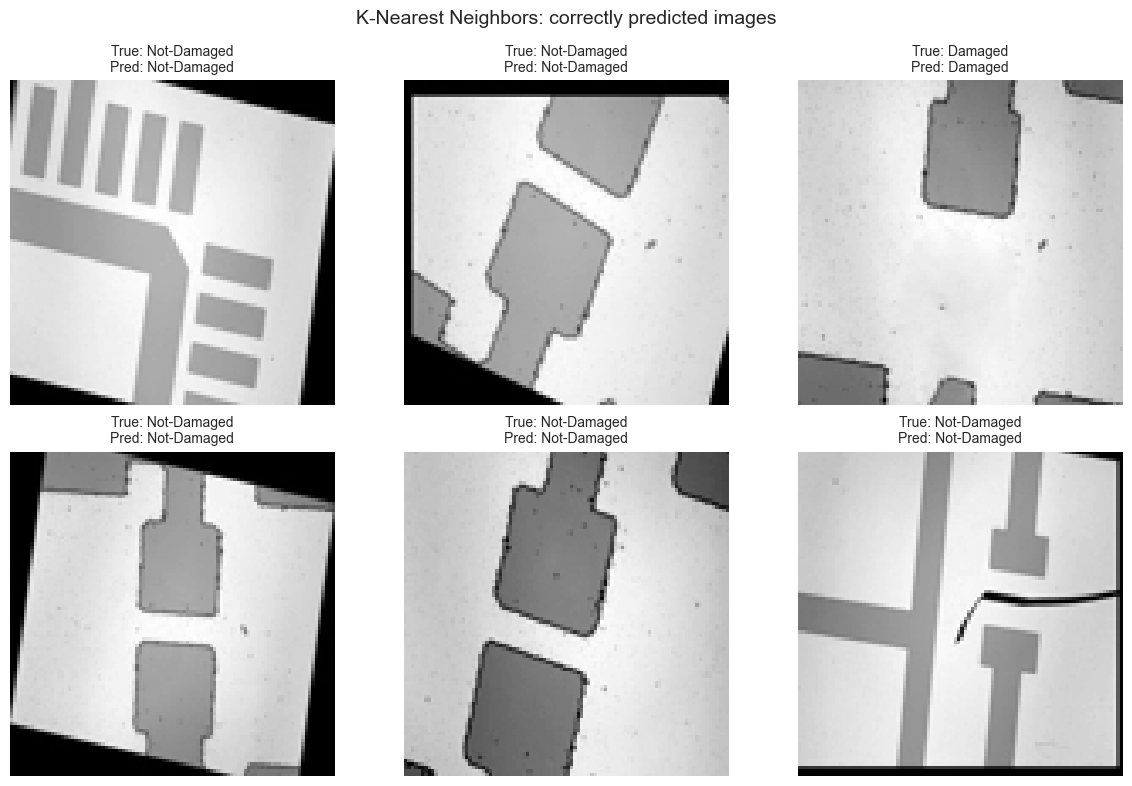

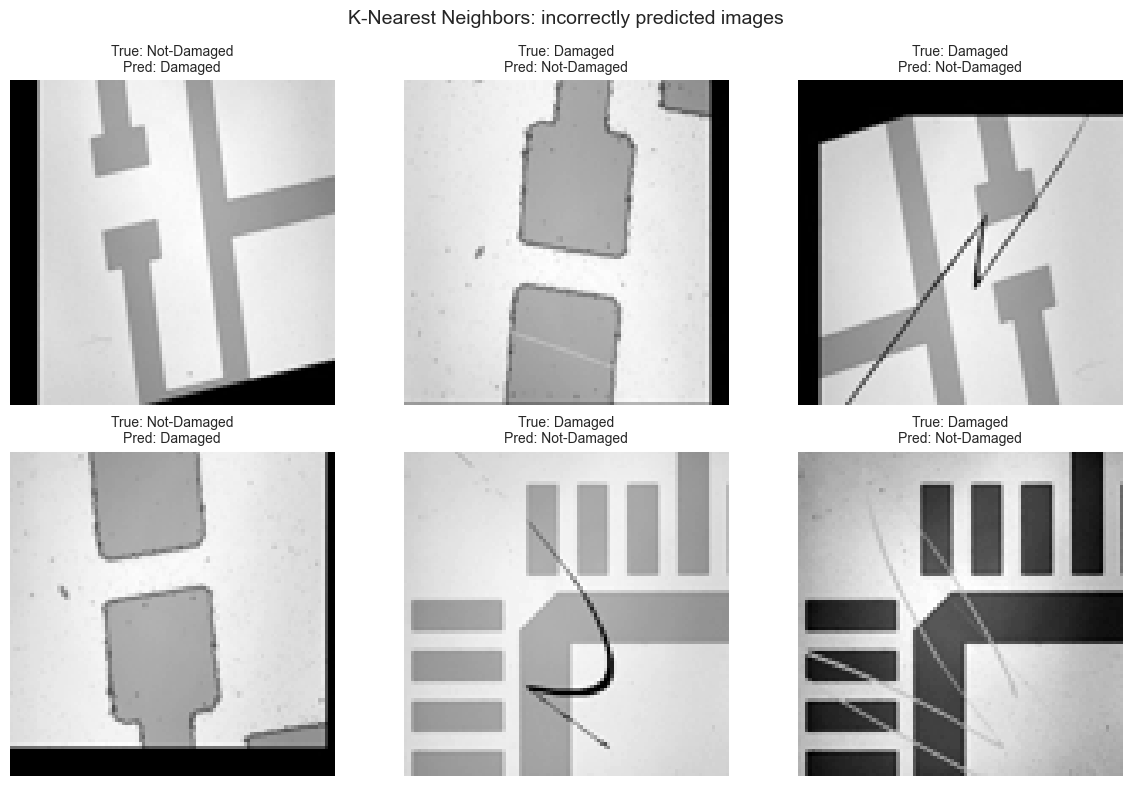

In [41]:
knn_model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=3)),
    ]
)
knn_results = fit_and_evaluate_classical_model(
    model_name="K-Nearest Neighbors",
    estimator=knn_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="knn",
    cmap="Purples",
)


## 12. Linear SVC

Linear SVC is another linear classifier. It predicts labels directly, but it does not provide class probabilities by default.

Hyperparameter notes:
- `max_iter=5000`: allows more optimization steps before the solver stops.
- `random_state=RANDOM_STATE`: keeps the run reproducible.
- `StandardScaler()`: helps linear margin-based models train more stably on pixel features.


Linear SVC training time: 0.89 seconds
Linear SVC prediction time: 0.0017 seconds
Linear SVC accuracy: 0.450
              precision    recall  f1-score   support

     Damaged       0.22      0.33      0.27        12
 Not-Damaged       0.64      0.50      0.56        28

    accuracy                           0.45        40
   macro avg       0.43      0.42      0.41        40
weighted avg       0.51      0.45      0.47        40



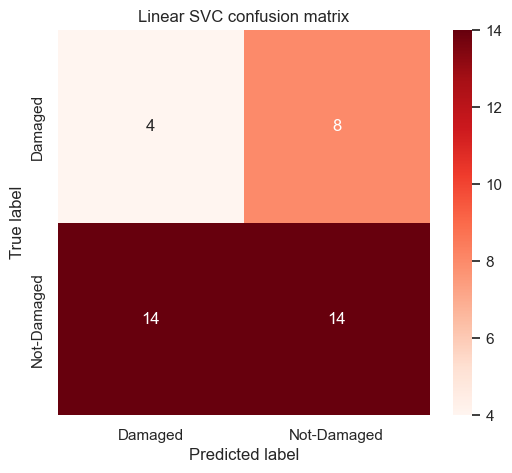

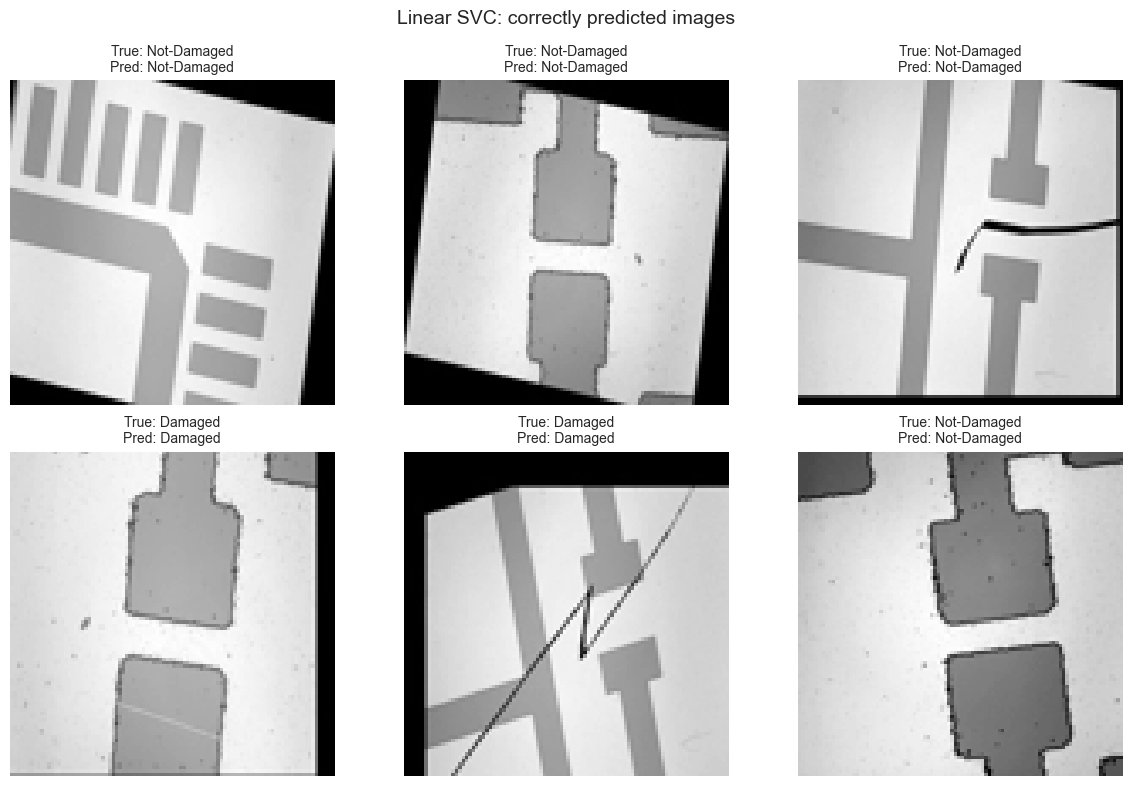

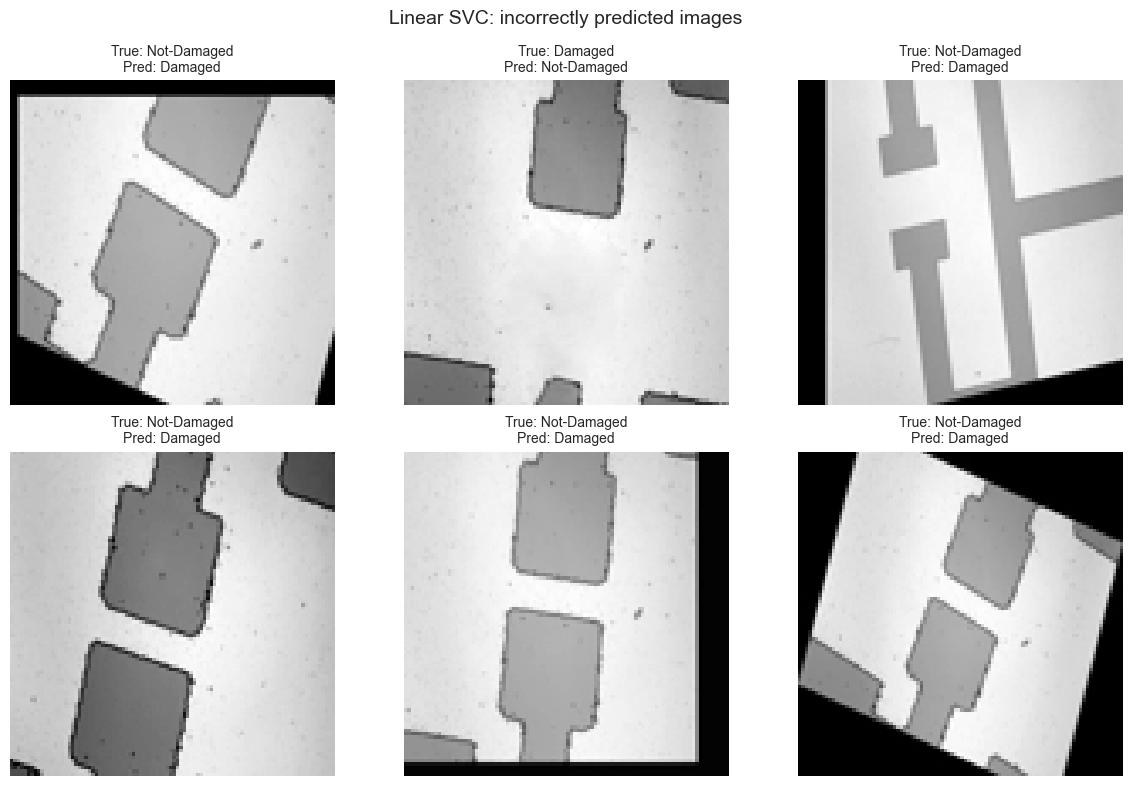

In [42]:
linear_svc_model = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("clf", LinearSVC(max_iter=5000, random_state=RANDOM_STATE)),
    ]
)
linear_svc_results = fit_and_evaluate_classical_model(
    model_name="Linear SVC",
    estimator=linear_svc_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    image_arrays=X_test,
    image_size=IMAGE_SIZE,
    timing_key="linear_svc",
    cmap="Reds",
)


## 13. Tiny CNN

Convolutional neural networks can learn spatial image patterns better than flattened classical baselines.

CNN hyperparameter notes:
- `CNN_IMAGE_SIZE=64`: every image is resized to `64 x 64` before entering the CNN.
- `CNN_EPOCHS=6`: the model sees the full training set 6 times. More epochs can improve learning, but too many can overfit.
- `CNN_BATCH_SIZE=8`: the optimizer updates after every 8 training images. Smaller batches are noisier; larger batches are steadier but use more memory.
- `CNN_LEARNING_RATE=0.001`: controls how large each Adam update is. Too high can make training unstable; too low can make learning very slow.

CNN architecture notes:
- `Conv2d(..., 16, kernel_size=3, padding=1)`: first convolution layer learns 16 feature maps from `3x3` image patches while preserving image size.
- `MaxPool2d(2)`: halves the spatial width and height, which reduces computation and keeps stronger signals.
- `Conv2d(16, 32, ...)`: second convolution layer learns 32 higher-level feature maps.
- `Linear(..., 64)`: dense hidden layer with 64 units after the convolution blocks.
- `Dropout(0.2)`: randomly turns off 20% of hidden units during training to reduce overfitting.
- `Linear(64, num_classes)`: final output layer, one score per class.


CNN preprocessing time: 0.88 seconds
CNN training time: 0.49 seconds
CNN prediction time: 0.0158 seconds
CNN accuracy: 0.700
              precision    recall  f1-score   support

     Damaged       0.00      0.00      0.00        12
 Not-Damaged       0.70      1.00      0.82        28

    accuracy                           0.70        40
   macro avg       0.35      0.50      0.41        40
weighted avg       0.49      0.70      0.58        40



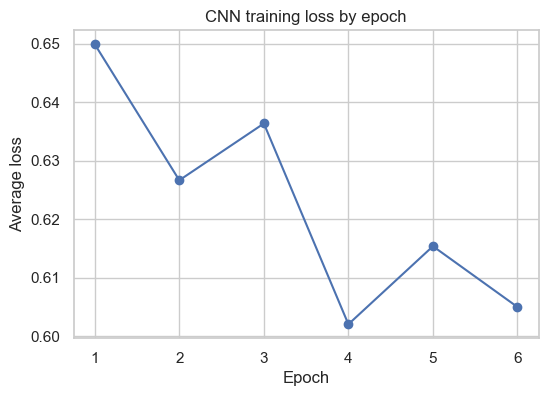

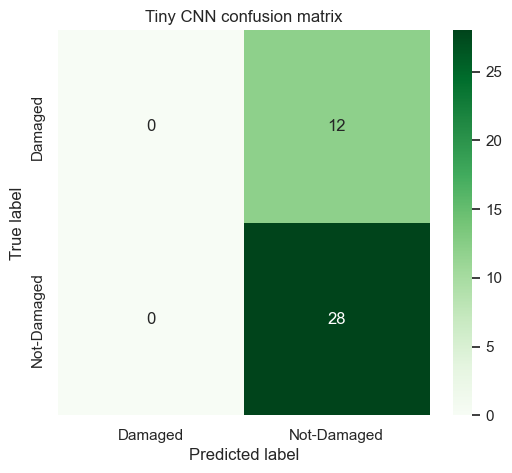

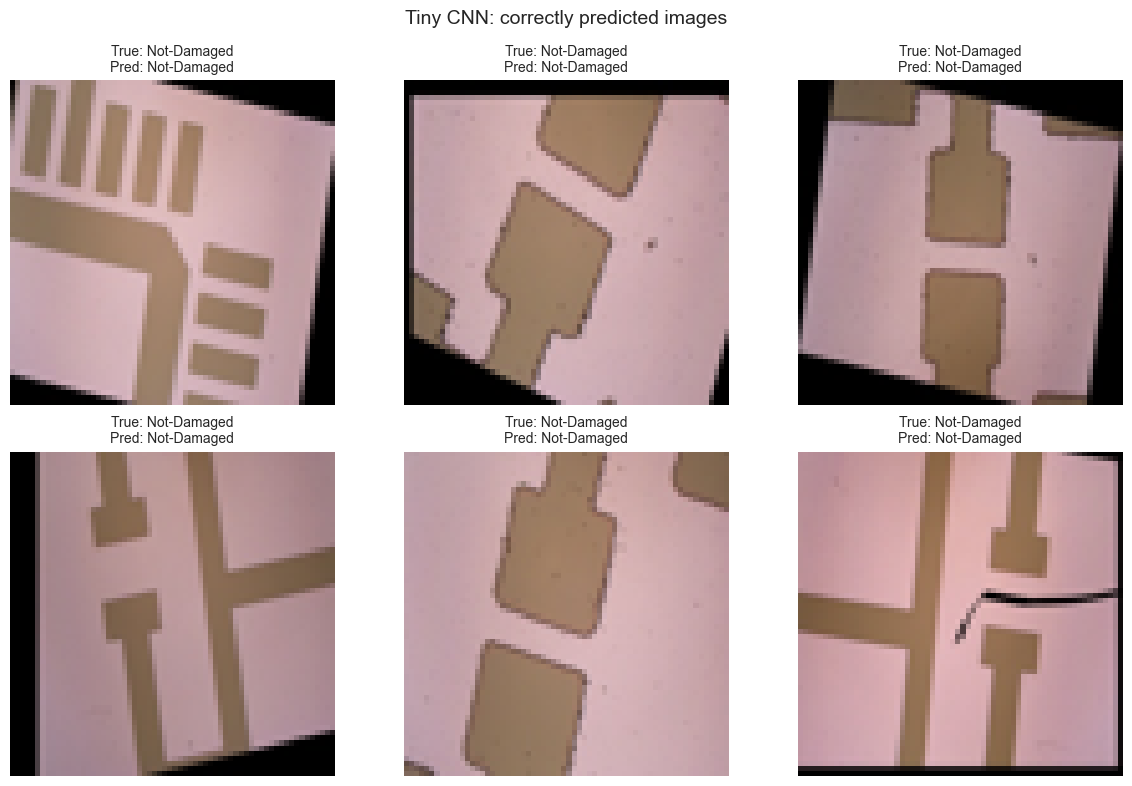

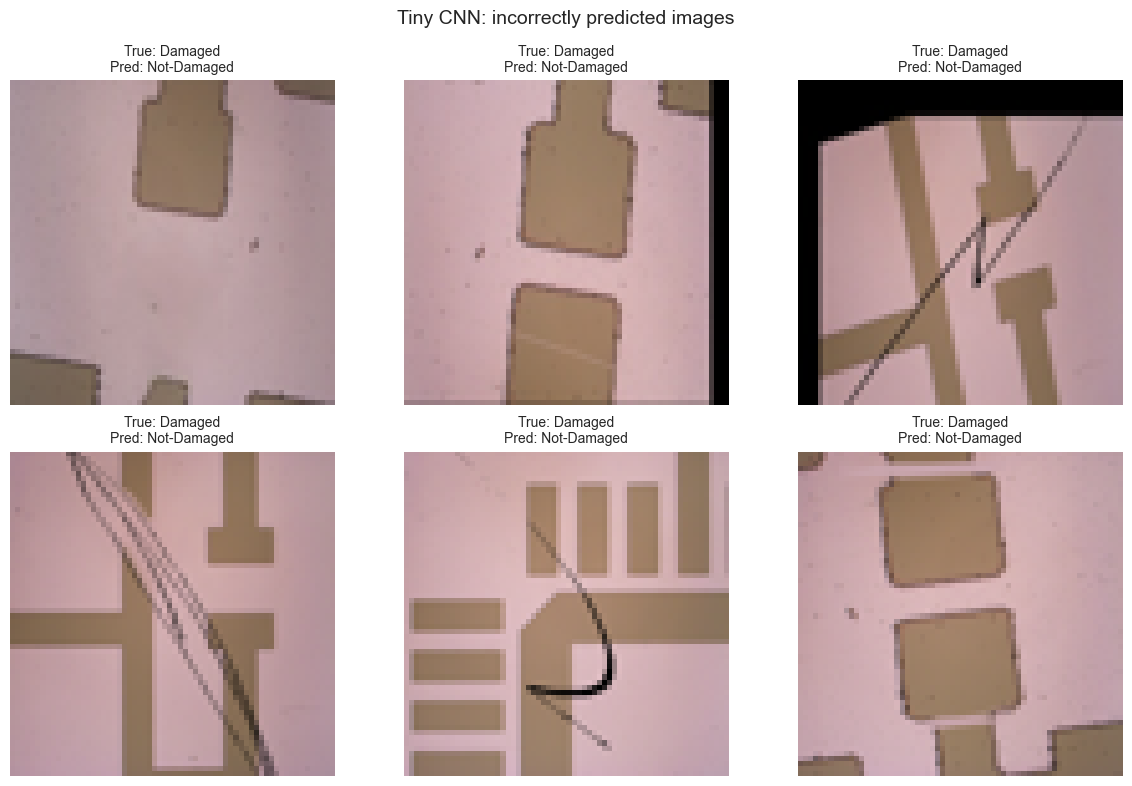

In [43]:
cnn_results = None
cnn_model = None
cnn_label_names = None
cnn_defect_challenge_records = None
cnn_defect_challenge_arrays = None

def _prepare_cnn_challenge_arrays(records):
    arrays, filtered = load_images_as_arrays(
        records,
        image_size=CNN_IMAGE_SIZE,
        color_mode="rgb",
        progress_title="CNN defect challenge",
    )
    return arrays, filtered

if not TORCH_AVAILABLE:
    display(Markdown("**CNN skipped:** install PyTorch from `requirements.txt` to run this section."))
else:
    started = time.perf_counter()
    cnn_arrays, cnn_records = load_images_as_arrays(
        filtered_records,
        image_size=CNN_IMAGE_SIZE,
        color_mode="rgb",
        progress_title="CNN images",
    )
    cnn_prep_elapsed = record_timing(step_timings, "cnn_preprocess", started)

    cnn_labels = cnn_records[target_column].astype(str).to_numpy()
    cnn_label_names = sorted(pd.unique(cnn_labels))
    label_to_index = {label: idx for idx, label in enumerate(cnn_label_names)}
    y_encoded = np.array([label_to_index[label] for label in cnn_labels])

    stratify_cnn = safe_stratify_labels(y_encoded)
    X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
        cnn_arrays,
        y_encoded,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_cnn,
    )

    X_train_tensor = torch.tensor(X_train_cnn.transpose(0, 3, 1, 2) / 255.0, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_cnn.transpose(0, 3, 1, 2) / 255.0, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_cnn, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test_cnn, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=CNN_BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=CNN_BATCH_SIZE, shuffle=False)

    class TinyCNN(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(32 * (CNN_IMAGE_SIZE // 4) * (CNN_IMAGE_SIZE // 4), 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, num_classes),
            )

        def forward(self, x):
            x = self.features(x)
            return self.classifier(x)

    cnn_model = TinyCNN(num_classes=len(cnn_label_names))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LEARNING_RATE)

    epoch_bar, epoch_status = create_progress("CNN epochs", CNN_EPOCHS)
    started = time.perf_counter()
    training_history = []

    for epoch in range(CNN_EPOCHS):
        cnn_model.train()
        epoch_loss = 0.0
        for batch_inputs, batch_targets in train_loader:
            optimizer.zero_grad()
            outputs = cnn_model(batch_inputs)
            loss = criterion(outputs, batch_targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_inputs)

        avg_loss = epoch_loss / len(train_loader.dataset)
        training_history.append(avg_loss)
        update_progress(
            epoch_bar,
            epoch_status,
            epoch + 1,
            f"Epoch {epoch + 1}/{CNN_EPOCHS} complete | average loss = {avg_loss:.4f}",
            done=epoch + 1 == CNN_EPOCHS,
        )

    cnn_train_elapsed = record_timing(step_timings, "cnn_train", started)

    started = time.perf_counter()
    cnn_model.eval()
    cnn_pred_indices = []
    cnn_truth_indices = []
    with torch.no_grad():
        for batch_inputs, batch_targets in test_loader:
            logits = cnn_model(batch_inputs)
            cnn_pred_indices.extend(torch.argmax(logits, dim=1).cpu().numpy())
            cnn_truth_indices.extend(batch_targets.cpu().numpy())
    cnn_predict_elapsed = record_timing(step_timings, "cnn_predict", started)

    cnn_pred_indices = np.array(cnn_pred_indices)
    cnn_truth_indices = np.array(cnn_truth_indices)
    decoded_preds = [cnn_label_names[idx] for idx in cnn_pred_indices]
    decoded_truths = [cnn_label_names[idx] for idx in cnn_truth_indices]
    cnn_accuracy = accuracy_score(decoded_truths, decoded_preds)

    print(f"CNN preprocessing time: {cnn_prep_elapsed:.2f} seconds")
    print(f"CNN training time: {cnn_train_elapsed:.2f} seconds")
    print(f"CNN prediction time: {cnn_predict_elapsed:.4f} seconds")
    print(f"CNN accuracy: {cnn_accuracy:.3f}")
    print(classification_report(decoded_truths, decoded_preds))

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, CNN_EPOCHS + 1), training_history, marker="o")
    plt.title("CNN training loss by epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss")
    plt.show()

    cnn_confidences = torch.softmax(torch.tensor(np.column_stack([np.zeros(len(cnn_pred_indices)), np.zeros(len(cnn_pred_indices))])), dim=1) if False else None
    with torch.no_grad():
        full_test_logits = cnn_model(X_test_tensor)
        full_test_probs = torch.softmax(full_test_logits, dim=1).cpu().numpy()
    cnn_confidences = full_test_probs.max(axis=1)
    evaluate_predictions(
        model_name="Tiny CNN",
        truths=decoded_truths,
        preds=decoded_preds,
        images=X_test_cnn,
        color_mode="rgb",
        image_size=None,
        cmap="Greens",
        confidences=cnn_confidences,
        confidence_label="Confidence",
    )

    cnn_results = {
        "model": "Tiny CNN",
        "accuracy": float(cnn_accuracy),
        "train_seconds": float(cnn_train_elapsed),
        "predict_seconds": float(cnn_predict_elapsed),
    }
    model_summaries.append({
        "model": "Tiny CNN",
        "accuracy": round(float(cnn_accuracy), 3),
        "train_seconds": round(float(cnn_train_elapsed), 3),
        "predict_seconds": round(float(cnn_predict_elapsed), 4),
    })

    if TARGET_MODE == "device_type" and RUN_DEFECT_CHALLENGE and not defect_challenge_records.empty:
        cnn_defect_challenge_arrays, cnn_defect_challenge_records = _prepare_cnn_challenge_arrays(defect_challenge_records)


## 14. Defect challenge set: extrapolation check

This section is only meaningful in `device_type` mode. These `Defect` images were not used for training or for the standard test split.


In [44]:
if TARGET_MODE != "device_type":
    display(Markdown("**Defect challenge skipped:** this section only runs for `device_type` mode."))
elif not RUN_DEFECT_CHALLENGE or defect_challenge_X is None or defect_challenge_gray_records is None or defect_challenge_gray_records.empty:
    display(Markdown("**Defect challenge skipped:** no damaged challenge images were prepared."))
else:
    defect_truths = defect_challenge_gray_records["device_type"].astype(str).tolist()

    logistic_challenge_pred = logistic_model.predict(defect_challenge_X)
    logistic_challenge_conf = None
    if hasattr(logistic_model, "predict_proba"):
        logistic_challenge_conf = logistic_model.predict_proba(defect_challenge_X).max(axis=1)
    logistic_challenge_accuracy = accuracy_score(defect_truths, logistic_challenge_pred)

    logistic_summary = defect_challenge_gray_records[["relative_path", "device_type"]].copy()
    logistic_summary = logistic_summary.rename(columns={"device_type": "true_device_type"})
    logistic_summary["logistic_predicted_device"] = logistic_challenge_pred
    logistic_summary["is_correct"] = logistic_summary["true_device_type"] == logistic_summary["logistic_predicted_device"]
    if logistic_challenge_conf is not None:
        logistic_summary["logistic_confidence"] = np.round(logistic_challenge_conf, 3)
    display(logistic_summary.head(10))

    print(f"Logistic Regression defect challenge accuracy: {logistic_challenge_accuracy:.3f}")
    evaluate_predictions(
        model_name="Logistic Regression defect challenge",
        truths=defect_truths,
        preds=list(logistic_challenge_pred),
        images=defect_challenge_X,
        color_mode="grayscale",
        image_size=IMAGE_SIZE,
        cmap="Blues",
        confidences=logistic_challenge_conf,
        confidence_label="Confidence",
    )

    if cnn_model is not None and cnn_defect_challenge_arrays is not None and cnn_defect_challenge_records is not None and not cnn_defect_challenge_records.empty:
        cnn_inputs = torch.tensor(cnn_defect_challenge_arrays.transpose(0, 3, 1, 2) / 255.0, dtype=torch.float32)
        cnn_model.eval()
        with torch.no_grad():
            cnn_logits = cnn_model(cnn_inputs)
            cnn_probs = torch.softmax(cnn_logits, dim=1).cpu().numpy()
        cnn_pred_idx = cnn_probs.argmax(axis=1)
        cnn_pred_labels = [cnn_label_names[idx] for idx in cnn_pred_idx]
        cnn_confidence = cnn_probs.max(axis=1)
        cnn_challenge_truths = cnn_defect_challenge_records["device_type"].astype(str).tolist()
        cnn_challenge_accuracy = accuracy_score(cnn_challenge_truths, cnn_pred_labels)

        cnn_summary = cnn_defect_challenge_records[["relative_path", "device_type"]].copy()
        cnn_summary = cnn_summary.rename(columns={"device_type": "true_device_type"})
        cnn_summary["cnn_predicted_device"] = cnn_pred_labels
        cnn_summary["is_correct"] = cnn_summary["true_device_type"] == cnn_summary["cnn_predicted_device"]
        cnn_summary["cnn_confidence"] = np.round(cnn_confidence, 3)
        display(cnn_summary.head(10))

        print(f"Tiny CNN defect challenge accuracy: {cnn_challenge_accuracy:.3f}")
        evaluate_predictions(
            model_name="Tiny CNN defect challenge",
            truths=cnn_challenge_truths,
            preds=cnn_pred_labels,
            images=cnn_defect_challenge_arrays,
            color_mode="rgb",
            image_size=None,
            cmap="Greens",
            confidences=cnn_confidence,
            confidence_label="Confidence",
        )


**Defect challenge skipped:** this section only runs for `device_type` mode.

## 15. Final comparison summary

This section compares the standard clean-test results across all available methods so students can see the tradeoffs in one place.


,step,seconds
0,dataset_scan,0.017
1,preprocess_images,1.750
2,logistic_train,0.100
3,logistic_predict,0.002
4,decision_tree_train,0.144
5,decision_tree_predict,0.001
6,knn_train,0.011
7,knn_predict,0.014
8,linear_svc_train,0.886
9,linear_svc_predict,0.002


,model,accuracy,train_seconds,predict_seconds
0,K-Nearest Neighbors,0.70,0.011,0.0140
1,Tiny CNN,0.70,0.491,0.0158
2,Logistic Regression,0.55,0.100,0.0019
3,Decision Tree,0.55,0.144,0.0011
4,Linear SVC,0.45,0.886,0.0017


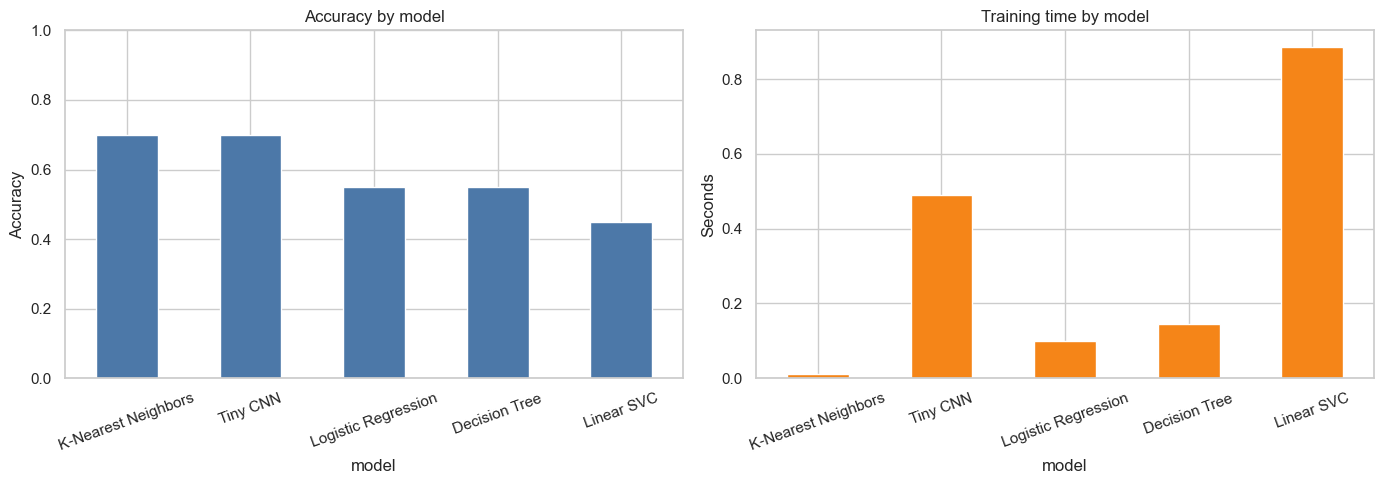

**Reflection prompts:** Which model was most accurate? Which was fastest? Did the most complex model always win? What tradeoffs mattered most for this dataset?

In [45]:
runtime_table = timing_frame(step_timings)
display(runtime_table)

comparison_table = pd.DataFrame(model_summaries)
comparison_table = comparison_table.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_table.plot(kind="bar", x="model", y="accuracy", color="#4c78a8", legend=False, ax=axes[0], title="Accuracy by model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

comparison_table.plot(kind="bar", x="model", y="train_seconds", color="#f58518", legend=False, ax=axes[1], title="Training time by model")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(Markdown(
    "**Reflection prompts:** Which model was most accurate? Which was fastest? "
    "Did the most complex model always win? What tradeoffs mattered most for this dataset?"
))


## 16. What students should notice

The dataset is small .

Reflect on these questions after running the notebook:
- Which model performed best on the clean test set?
- Which model trained fastest?
- Did the more complex model always win?
- How did the models behave on damaged images compared with the clean test split?
- Would you trust high confidence on the defect challenge set if there is no true label to compare against?
- Could augmentation improve fairness across classes?

Next step:
- use the augmentation notebook to generate a larger training set without editing the original image folders.
